# LightGBM Thunderstorm Prediction
Train: 2000-2020
Validation: 2021-2022
Test: 2023-2025

In [1]:
!pip install lightgbm optuna shap joblib -q

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import *


In [6]:
train=pd.read_csv("../Data/train_2000_2020.csv")
valid=pd.read_csv("../Data/validation_2021_2022.csv")
test=pd.read_csv("../Data/test_2023_2025.csv")

target="Thunderstorm_24h"

drop_cols=[target]
for c in ["Date","Time","DATE","TIME","date","time"]:
    if c in train.columns:
        drop_cols.append(c)

X_train=train.drop(columns=drop_cols)
y_train=train[target]

X_valid=valid.drop(columns=drop_cols)
y_valid=valid[target]

X_test=test.drop(columns=drop_cols)
y_test=test[target]

print(X_train.shape,X_valid.shape,X_test.shape)


(9619, 25) (580, 25) (1392, 25)


In [7]:
def objective(trial):

    params={
        "objective":"binary",
        "metric":"binary_logloss",
        "learning_rate":trial.suggest_float("learning_rate",0.005,0.1,log=True),
        "num_leaves":trial.suggest_int("num_leaves",31,255),
        "max_depth":trial.suggest_int("max_depth",4,12),
        "min_child_samples":trial.suggest_int("min_child_samples",5,100),
        "feature_fraction":trial.suggest_float("feature_fraction",0.6,1.0),
        "bagging_fraction":trial.suggest_float("bagging_fraction",0.6,1.0),
        "bagging_freq":trial.suggest_int("bagging_freq",1,10),
        "lambda_l1":trial.suggest_float("lambda_l1",0,10),
        "lambda_l2":trial.suggest_float("lambda_l2",0,10),
        "class_weight":"balanced",
        "n_estimators":4000,
        "random_state":42,
        "verbosity":-1
    }

    model=lgb.LGBMClassifier(**params)

    model.fit(
        X_train,y_train,
        eval_set=[(X_valid,y_valid)],
        eval_metric="binary_logloss",
        callbacks=[
            lgb.early_stopping(200,verbose=False)
        ]
    )

    p=model.predict_proba(X_valid)[:,1]
    pred=(p>=0.5).astype(int)

    return f1_score(y_valid,pred)

study=optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=50)

best=study.best_params
print(best)


[I 2026-07-12 21:05:32,129] A new study created in memory with name: no-name-7cb622c1-8329-43ca-ae52-0fdaeedd48bf
[I 2026-07-12 21:09:09,149] Trial 0 finished with value: 0.5213675213675214 and parameters: {'learning_rate': 0.005490582412654004, 'num_leaves': 81, 'max_depth': 12, 'min_child_samples': 57, 'feature_fraction': 0.7496183837926325, 'bagging_fraction': 0.8485143357289193, 'bagging_freq': 10, 'lambda_l1': 0.5926407246774335, 'lambda_l2': 4.226678838343196}. Best is trial 0 with value: 0.5213675213675214.
[I 2026-07-12 21:09:35,272] Trial 1 finished with value: 0.5042735042735043 and parameters: {'learning_rate': 0.019823483574032054, 'num_leaves': 155, 'max_depth': 5, 'min_child_samples': 22, 'feature_fraction': 0.6331002318438975, 'bagging_fraction': 0.8433090142706499, 'bagging_freq': 5, 'lambda_l1': 2.4128867164485666, 'lambda_l2': 3.8098931130361766}. Best is trial 0 with value: 0.5213675213675214.
[I 2026-07-12 21:09:52,091] Trial 2 finished with value: 0.509652509652509

{'learning_rate': 0.02474965367743785, 'num_leaves': 185, 'max_depth': 10, 'min_child_samples': 12, 'feature_fraction': 0.9207116051626851, 'bagging_fraction': 0.9076559034865189, 'bagging_freq': 2, 'lambda_l1': 4.332378684164573, 'lambda_l2': 7.8246451974311855}


In [8]:
best.update({
    "objective":"binary",
    "class_weight":"balanced",
    "n_estimators":4000,
    "random_state":42
})

model=lgb.LGBMClassifier(**best)

model.fit(
    X_train,y_train,
    eval_set=[(X_valid,y_valid)],
    callbacks=[
        lgb.early_stopping(200),
        lgb.log_evaluation(100)
    ]
)


Training until validation scores don't improve for 200 rounds
[100]	valid_0's binary_logloss: 0.442894
[200]	valid_0's binary_logloss: 0.417822
[300]	valid_0's binary_logloss: 0.405243
[400]	valid_0's binary_logloss: 0.396505
[500]	valid_0's binary_logloss: 0.389657
[600]	valid_0's binary_logloss: 0.386683
[700]	valid_0's binary_logloss: 0.387928
[800]	valid_0's binary_logloss: 0.387399
Early stopping, best iteration is:
[600]	valid_0's binary_logloss: 0.386683


,num_leaves,185
,max_depth,10
,learning_rate,0.02474965367743785
,n_estimators,4000
,objective,'binary'
,class_weight,'balanced'
,min_child_samples,12
,random_state,42
,feature_fraction,0.9207116051626851
,bagging_fraction,0.9076559034865189
,bagging_freq,2


In [9]:
thresholds=np.arange(0.10,0.91,0.01)

best_thr=0.5
best_f1=0

val_prob=model.predict_proba(X_valid)[:,1]

for t in thresholds:
    pred=(val_prob>=t).astype(int)
    f1=f1_score(y_valid,pred)
    if f1>best_f1:
        best_f1=f1
        best_thr=t

print(best_thr,best_f1)


0.5399999999999998 0.5585585585585585


Validation
              precision    recall  f1-score   support

           0     0.9354    0.8589    0.8955       489
           1     0.4733    0.6813    0.5586        91

    accuracy                         0.8310       580
   macro avg     0.7043    0.7701    0.7270       580
weighted avg     0.8629    0.8310    0.8427       580

ROC AUC: 0.84136722173532


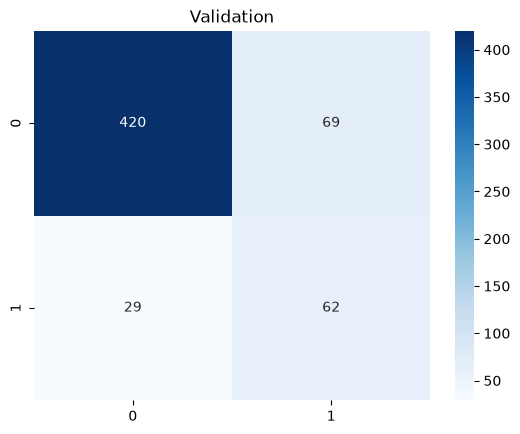

Testing
              precision    recall  f1-score   support

           0     0.9330    0.8113    0.8679      1219
           1     0.3072    0.5896    0.4040       173

    accuracy                         0.7838      1392
   macro avg     0.6201    0.7005    0.6359      1392
weighted avg     0.8552    0.7838    0.8103      1392

ROC AUC: 0.8050946715539601


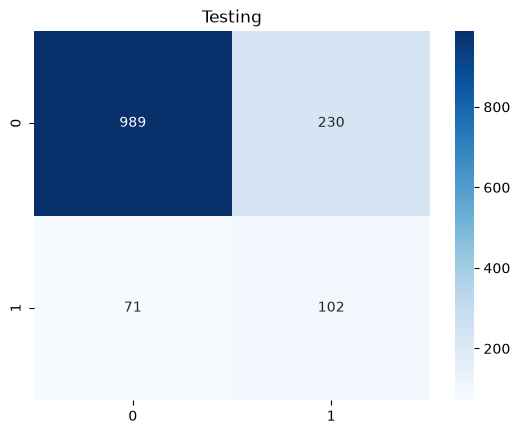

In [10]:
def evaluate(X,y,name):
    prob=model.predict_proba(X)[:,1]
    pred=(prob>=best_thr).astype(int)

    print(name)
    print(classification_report(y,pred,digits=4))
    print("ROC AUC:",roc_auc_score(y,prob))

    cm=confusion_matrix(y,pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
    plt.title(name)
    plt.show()

    return prob,pred

val_prob,val_pred=evaluate(X_valid,y_valid,"Validation")
test_prob,test_pred=evaluate(X_test,y_test,"Testing")


In [11]:
results=test.copy()
results["Probability"]=test_prob
results["Prediction"]=test_pred
results.to_csv("../Data/LightGBM_Test_Predictions.csv",index=False)

fi=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":model.feature_importances_
}).sort_values("Importance",ascending=False)

fi.to_csv("../Data/Feature_Importance.csv",index=False)

joblib.dump(model,"../Data/LightGBM_Thunderstorm_Model.pkl")

fi.head(30)


,Feature,Importance
19,LCL_P,4757
22,MML_MR,4411
21,MML_PT,4072
3,SWEAT,3959
24,PW,3860
4,KI,3692
15,LFC_V,3688
14,LFC,3682
16,BRN,3334
18,LCL_T,3021


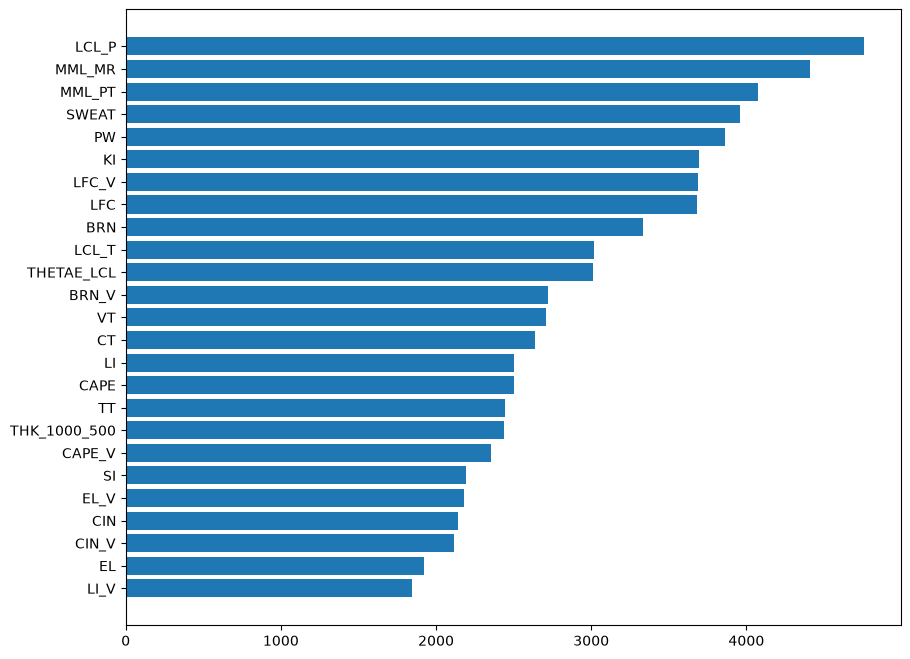

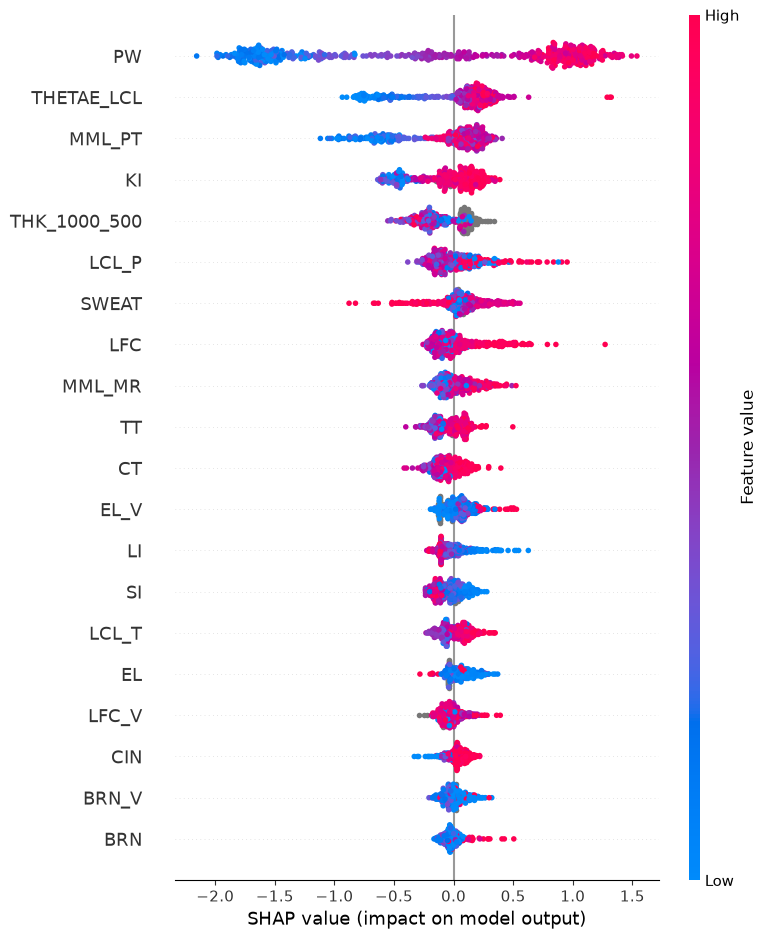

In [12]:
plt.figure(figsize=(10,8))
top=fi.head(30)
plt.barh(top.Feature,top.Importance)
plt.gca().invert_yaxis()
plt.show()

explainer=shap.TreeExplainer(model)
sample=X_test.sample(min(500,len(X_test)),random_state=42)
sv=explainer.shap_values(sample)
shap.summary_plot(sv,sample)
